In [2]:
import numpy as np
import pandas as pd
from functools import reduce
from sklearn.linear_model import Ridge, LinearRegression
import matplotlib.pyplot as plt

In [3]:
def returns(price, h):
    return np.log(price.shift(-h) / price) #forward returns; r_{t}^{(h)} = log(P_{t+h}/P_t).
                                           #shift(-h) keeps the index where it is and moves
                                           #all observations up by h. Ie, the observation at
                                           #t+h ends up at index t. we then divide them.
                                           #Last h observations in the df will be NaN.
def momentum(price, h):
    return np.log(price/price.shift(h))    #Define the momentum at t as the backward-looking return
                                           #over the time period from t-h to t. shift(h) moves 
                                           #all observations down by h, so the observation at t-h
                                           #ends up at t. A recent positive return might indicate
                                           #that returns will continue being positive in the future.
def realisedvol(price, h):
    returns = np.log(price).diff()
    vol = returns.rolling(h).std() 
    return np.sqrt(252) * vol.shift(1)     #Define the realised vol over time period h as the rolling
                                           #std over period h of the backward-looking daily returns.

def sharpe_ratio(returns, periods_per_year=252):
    returns = np.array(returns.dropna())
    if len(returns) < 2:
        return np.nan

    vol = returns.std()
    if vol == 0:
        return np.nan

    return (returns.mean() / vol) * np.sqrt(periods_per_year) #Sharpe; expected return over vol

def max_drawdown(cumulative_returns):
    peak = cumulative_returns.cummax()
    drawdown = (cumulative_returns - peak) / peak #Compute % drawdown
    return drawdown.min() #return the most negative result

Now we've defined our imports & some basic functions, we import the data we'll use. We're interested in 10Y government bond futures, and we'll use data across 6 markets - US, UK, Germany, Canada, France & Italy. We'll also import data for the MOVE index, as well as 2, 5 & 10Y US Treasury yields. 

In [4]:
USdict_10y = {"Price" : "10Y US Price"}
UKdict_10y = {"Price" : "10Y UK Price"}
Gerdict_10y = {"Price" : "10Y Ger Price"}
Caddict_10y = {"Price" : "10Y Cad Price"}
Frdict_10y = {"Price" : "10Y Fr Price"}
Itdict_10y = {"Price" : "10Y It Price"}
dict_move = {"Price" : "MOVE Price"}
dict_dgs2 = {"Price" : "DGS2 Price"}
dict_dgs5 = {"Price" : "DGS5 Price"}
dict_dgs10 = {"Price" : "DGS10 Price"}

USfut_10y = pd.read_csv("data/US 10 YR T-Note June Futures Historical Data.csv").rename(columns = USdict_10y)[["Date", "10Y US Price"]]
UKfut_10y = pd.read_csv("data/UK 10 YR Gilt March Futures Historical Data.csv").rename(columns = UKdict_10y)[["Date", "10Y UK Price"]]
Gerfut_10y = pd.read_csv("data/German 10 YR Bund June Futures Historical Data.csv").rename(columns = Gerdict_10y)[["Date", "10Y Ger Price"]]
Cadfut_10y = pd.read_csv("data/Canada Government Bond 10Y Futures Historical Data.csv").rename(columns = Caddict_10y)[["Date", "10Y Cad Price"]]
Frfut_10y = pd.read_csv("data/Euro OAT Futures Historical Data.csv").rename(columns = Frdict_10y)[["Date", "10Y Fr Price"]]
Itfut_10y = pd.read_csv("data/Italian 10 YR BTP June Futures Historical Data.csv").rename(columns = Itdict_10y)[["Date", "10Y It Price"]]
move = pd.read_csv("data/ICE BofAML MOVE Historical Data.csv").rename(columns = dict_move)[["Date", "MOVE Price"]]
DGS2 = pd.read_csv("data/DGS2.csv")[["Date", "Price"]].rename(columns = dict_dgs2) #2Y Treasury yields
DGS5 = pd.read_csv("data/DGS5.csv")[["Date", "Price"]].rename(columns = dict_dgs5) #5Y Treasury yields
DGS10 = pd.read_csv("data/DGS10.csv")[["Date", "Price"]].rename(columns = dict_dgs10) #10Y Treasury yields

We should be clear that we have made no effort to ensure that the data is free from jumps due to contract rolls. Our aim here is to give a proof-of-concept & demonstrate some concepts in predictive modelling, not to generate real & tradeable alpha.

Clean up; sort, drop dups & make sure dates are the right format

In [5]:
for df in [DGS2, DGS5, DGS10]:
    df["Date"] = pd.to_datetime(df["Date"], errors = "coerce") #Set a non-date to NotATime
    df.sort_values("Date", inplace=True)
    df.drop_duplicates(subset="Date", keep="first", inplace=True)

yields = reduce(lambda left, right: pd.merge(left, right, on = "Date", how = "outer"), [DGS2, DGS5, DGS10]).dropna()
#reduce applies the operation to the first two elements in the sequence, then to the result and the third, etc. 
#In this case the operation is an outer merge

Tfut_list = [USfut_10y, UKfut_10y, Gerfut_10y, Cadfut_10y, Frfut_10y, Itfut_10y, move]

for df in Tfut_list:
    df["Date"] = pd.to_datetime(df["Date"], errors = "coerce", dayfirst = True)
    df.sort_values("Date", inplace=True)
    df.drop_duplicates(subset="Date", keep="first", inplace=True)

Tfut = reduce(lambda left, right: pd.merge(left, right, on = "Date", how = "outer"), Tfut_list).dropna()
master = reduce(lambda left, right: pd.merge(left, right, on = "Date", how = "inner"), [Tfut, yields]).dropna()
#final join is an inner, to only keep dates that are common to both yields and the futures
master = master.sort_values("Date")
master = master.set_index("Date")


Now we start computing targets & features. Our targets will be forward-looking vol-scaled returns over a specified horizon h, for each country's futures:

In [6]:
h = 25 #Predict h days ahead, pick h = 25 for now
countries = ["US", "UK", "Ger", "Cad", "Fr", "It"]
for country in countries:
    master[f"10Y_{country}_Returns"] = returns(master[f"10Y {country} Price"], h)
    master[f"10Y_{country}_Vol"] = realisedvol(master[f"10Y {country} Price"], h)

for country in countries: 
    master[f"{country}_target"] = master[f"10Y_{country}_Returns"]/master[f"10Y_{country}_Vol"]
    
master = master.dropna(subset=["US_target", "UK_target", "Ger_target", "Cad_target", "Fr_target", "It_target"])


Our features are basic momentum, the h-day change in the MOVE index, curve spread & fly for US bonds, and some interactions between curve spread & momentum.

In [7]:
#Momentum:
lookback = 50
for country in countries:
    master[f"{country}_mom"] = momentum(master[f"10Y {country} Price"], lookback) 

#MOVE change
master["MOVE_change"] = master["MOVE Price"].diff(h)

#Spread & fly for US yields, maybe some predictive power for the other countries
master["US_2s10s"] = (master["DGS10 Price"] - master["DGS2 Price"])
master["US_2s5s10s"] = (master["DGS2 Price"] - 2*master["DGS5 Price"] + master["DGS10 Price"])

#Interactions
for country in countries:
    master[f"Curve x {country} momentum"] = master["US_2s10s"] * master[f"{country}_mom"]


#Feature columns
feature_cols = []
for country in countries:
    feature_cols.append(f"{country}_mom")
for country in countries:
    feature_cols.append(f"Curve x {country} momentum")
    
feature_cols.extend(["MOVE_change", "US_2s10s", "US_2s5s10s"])
master[feature_cols] = master[feature_cols].shift(1)
master[feature_cols]

,US_mom,UK_mom,Ger_mom,Cad_mom,Fr_mom,It_mom,Curve x US momentum,Curve x UK momentum,Curve x Ger momentum,Curve x Cad momentum,Curve x Fr momentum,Curve x It momentum,MOVE_change,US_2s10s,US_2s5s10s
Date,,,,,,,,,,,,,,,
2012-10-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2012-10-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.719,0.509
2012-10-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.706,0.622
2012-10-05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.696,0.568
2012-10-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.612,0.608
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-08-05,0.018138,-0.013823,-0.022843,0.043880,-0.001291,0.015033,0.010176,-0.007755,-0.012815,0.024617,-0.000725,0.008433,-16.16,0.561,0.183
2025-08-07,0.024793,-0.000216,-0.021403,0.020461,0.001292,0.021215,0.012396,-0.000108,-0.010702,0.010231,0.000646,0.010607,-17.19,0.500,0.284
2025-08-08,0.017096,-0.011407,-0.019542,-0.001904,0.001699,0.021392,0.008685,-0.005795,-0.009927,-0.000967,0.000863,0.010867,-31.85,0.508,0.352


We are now going to stack these features into a panel, and perform a ridge regression on that panel.

In [8]:
panel_list = [] #This will be a list of 1 df for each country
for country in countries:
    panel_dict = {"Date" : master.index, "Asset" : country, "Target" : master[f"{country}_target"], \
                 "Momentum" : master[f"{country}_mom"], "MOVE_change" : master["MOVE_change"], \
                 "US_slope" : master["US_2s10s"], "US_fly" : master["US_2s5s10s"], \
                 "ForwardReturn" : master[f"10Y_{country}_Returns"], "DailyReturn" : np.log(master[f"10Y {country} Price"]/master[f"10Y {country} Price"].shift(1)), \
                 "Interaction" : master[f"Curve x {country} momentum"],} #The strings are the column headers
    tmp = pd.DataFrame(panel_dict)
    panel_list.append(tmp)

panel = pd.concat(panel_list).set_index("Date") #concatenate each df into a single panel df
panel["Momentum"] = panel.groupby(panel.index)["Momentum"].transform(lambda x : (x - x.mean())/x.std())
panel.dropna(inplace = True)
panel

,Asset,Target,Momentum,MOVE_change,US_slope,US_fly,ForwardReturn,DailyReturn,Interaction
Date,,,,,,,,,
2013-07-05,US,0.089998,-1.058186,44.50,1.741,0.541,0.010216,-0.013545,-0.096740
2013-07-08,US,0.020248,-1.124772,58.00,1.556,0.508,0.002392,0.004961,-0.108235
2013-07-10,US,0.027192,-0.970149,46.30,2.294,0.166,0.003267,0.000000,-0.144409
2013-07-11,US,-0.049496,-0.997002,39.20,2.285,0.169,-0.005955,0.008188,-0.135263
2013-08-01,US,-0.155870,-0.711595,38.50,2.316,0.274,-0.018271,-0.007390,-0.120399
...,...,...,...,...,...,...,...,...,...
2025-08-05,It,-0.159371,0.351228,-16.16,0.561,0.183,-0.015262,0.001400,0.008433
2025-08-07,It,-0.047484,0.758791,-17.19,0.500,0.284,-0.003961,-0.000412,0.010607
2025-08-08,It,-0.019891,1.270837,-31.85,0.508,0.352,-0.001654,-0.003547,0.010867


Now we can start modelling. Given that we only have a universe of 6 assets, and that the features are likely to be highly correlated, standard linear regression is likely to be unstable; small changes in the input data are likely to produce large changes in the learned coefficients. To mitigate this, we should use some kind of regularisation method. Here, we choose ridge regression to improve coefficient stability.

We'll perform a rolling regression. That is, for each day t in the dataset, we:
1) Look back a specified number of days, which we'll call rolling_window,
2) Train the model on the last rolling_window's worth of days,
3) Predict that day's cross-section,
4) Move forward one day,
5) Repeat.

The reason we do this is so that the model parameters adapt to market regime - if we just trained on the entire dataset we'd be treating market conditions as identical across time, which is clearly not correct. Ie, April 2025 (tarriffs) does not represent the same market conditions as early 2020 (COVID selloff), which does not represent the same market conditions as the post-covid hiking cycle.

We also keep the momentum feature in the dataset for later analysis.

In [9]:
rolling_window = 252
panel = panel.sort_index()
dates = panel.index.unique() #get the unique dates out of the panel

#Features & target cols
X_cols = ["Momentum", "MOVE_change", "US_slope", "US_fly", "Interaction"]
y_col = "Target"

#predictions list
predictions = []

for t in range(rolling_window, len(dates) - h):
    train_dates = dates[t - rolling_window : t - h]
    test_date = dates[t]
    train_df = panel.loc[train_dates].dropna()
    test_df = panel.loc[[test_date]].dropna()

    X_train = train_df[X_cols].values
    mu = X_train.mean(axis=0)  
    sigma = X_train.std(axis=0) 

    X_train = (X_train - mu) / sigma 
    y_train = train_df[y_col].values
    X_test = test_df[X_cols].values 
    X_test  = (X_test  - mu) / sigma

    #Train ridge regression model:
    model = Ridge(alpha = 1.0)
    model.fit(X_train, y_train)

    #Predict: 
    preds = model.predict(X_test)
    pred_dict = {"Date" : test_df.index, "Asset" : test_df["Asset"].values, "Prediction" : preds, \
                "Target" : test_df[y_col].values, "DailyReturn" : test_df["DailyReturn"].values, "Momentum" : test_df["Momentum"].values,\
                "MOVE_change" : test_df["MOVE_change"].values, "US_slope" : test_df["US_slope"].values,"US_fly" : test_df["US_fly"].values,\
                "Interaction" : test_df["Interaction"].values}
    out = pd.DataFrame(pred_dict)
    predictions.append(out)

pred_df = pd.concat(predictions)
pred_df.set_index("Date", inplace=True)
print(pred_df)

           Asset  Prediction    Target  DailyReturn  Momentum  MOVE_change  \
Date                                                                         
2017-07-07   Cad   -0.068819  0.003776    -0.011064  0.383413       -10.43   
2017-07-07    UK   -0.069324  0.006455     0.001600  0.363637       -10.43   
2017-07-07    Fr   -0.112841  0.536728    -0.001359 -1.338949       -10.43   
2017-07-07    It   -0.099427  0.390066    -0.005479 -0.814115       -10.43   
2017-07-07   Ger   -0.040228  0.114133    -0.000062  1.501993       -10.43   
...          ...         ...       ...          ...       ...          ...   
2025-04-11    Fr   -0.309135 -0.066461     0.002909  0.234023        31.02   
2025-04-11    It   -0.333261  0.154548     0.004498  0.714563        31.02   
2025-04-11    UK   -0.196305  0.008654     0.010047 -2.013303        31.02   
2025-04-11    US   -0.316384  0.199902    -0.005453  0.378415        31.02   
2025-04-11   Cad   -0.316403  0.009254     0.007209  0.378786   

We've implicitly produced a ranking, on each day in the dataset, of which country's futures to long and which to short. The idea is that we construct a relative value portfolio; we go long the assets predicted to perform the best (even if they're expected to decline) and short the assets predicted to perform the worst (even if they're expected to increase in value). The inefficiency that this captures is the mispricing of short-term risk-adjusted returns across different countries' bond futures, the hypothesis being that momentum & curve structure take time to become fully priced in.

In theory, such a relative value portfolio can generate positive returns even in an overall-declining market, and even if we get the absolute direction of individual assets wrong — as long as we are correct about the relative ranking of their expected performance. This would not be the case if we simply went long every asset with a positive predicted return and short every asset with a negative predicted return: in that scenario, if all predictions are positive and the market turns down, the portfolio would lose money. In contrast, the relative value portfolio profits from differences between assets rather than from the market’s absolute direction.

We now want to evaluate the model. First we compute the Information Coefficient, defined as the pearson correlation between the target and model's predictions.

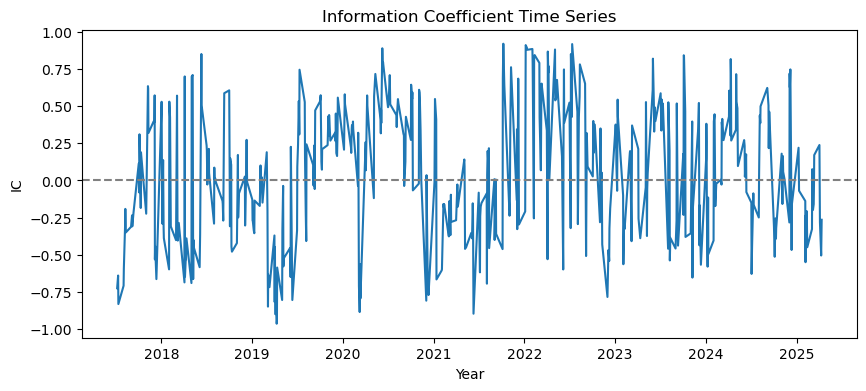

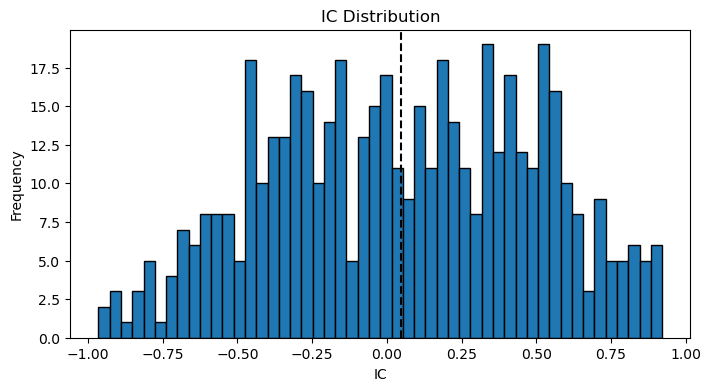

Mean IC: 0.048131346859731486
Std of IC: 0.44040561786646837
IC t-stat: 2.443769086061311


In [10]:
ic = pred_df.groupby(pred_df.index).apply(lambda df : df["Prediction"].corr(df["Target"]))
#We split into dataframes that each have 6 rows (1 for each asset) 
#where the date is identical on each row (this is groupby), and then compute the correlation

plt.figure(figsize=(10,4))
plt.plot(ic)
plt.axhline(0, linestyle="--", color = "gray")
plt.title("Information Coefficient Time Series")
plt.xlabel("Year")
plt.ylabel("IC")
plt.savefig("IC_time_series.pdf")
plt.show()

plt.figure(figsize=(8,4))
plt.hist(ic, bins=50, edgecolor = "black")
plt.axvline(ic.mean(), linestyle="--", color = "black")
plt.title("IC Distribution")
plt.xlabel("IC")
plt.ylabel("Frequency")
plt.savefig("IC_dist.pdf")
plt.show()

print("Mean IC:", ic.mean())
print("Std of IC:", ic.std())
print("IC t-stat:", ic.mean() / ic.std() * np.sqrt(len(ic)))

Now we construct the portfolio. We want to centre the weights around zero.

In [11]:
def centre(x): return x - x.mean()
    
#Centre the predictions
pred_df["Weight"] = pred_df.groupby(pred_df.index)["Prediction"].transform(centre)
#Compute the weights
pred_df["Weight"] = pred_df.groupby(pred_df.index)["Weight"].transform(lambda x : x/np.sum(np.abs(x)))
pred_df["Weight"] = pred_df.groupby("Asset")["Weight"].shift(1)
pred_df.dropna(inplace = True)
print(pred_df[["Asset", "Weight"]])

           Asset    Weight
Date                      
2017-07-11   Cad  0.085239
2017-07-11    UK  0.080843
2017-07-11   Ger  0.333918
2017-07-11    US -0.021338
2017-07-11    It -0.180991
...          ...       ...
2025-04-11    Fr  0.068979
2025-04-11    It -0.108825
2025-04-11    UK  0.324517
2025-04-11    US -0.155968
2025-04-11   Cad -0.235207

[2994 rows x 2 columns]


Returns of the strategy are the returns * portfolio weights:

In [12]:
pred_df["StrategyReturns"] = pred_df["Weight"] * pred_df["DailyReturn"]

We also compute the turnover; the absolute change in portflio weights per day. This tells you how much you're rebalancing the portfolio each day, which we'll use to compute cost-adjusted returns later.

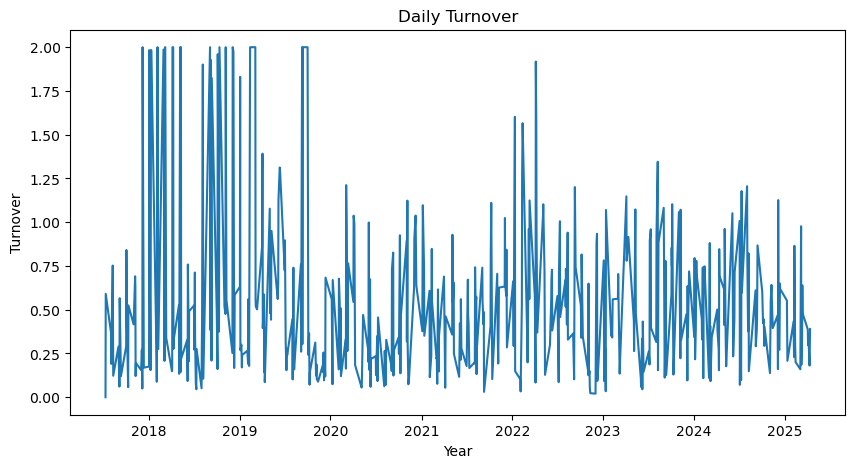

In [13]:
pred_df["PrevWeight"] = pred_df.groupby("Asset")["Weight"].shift(1)
pred_df["Turnover"] = np.abs(pred_df["Weight"] - pred_df["PrevWeight"])

daily_turnover = pred_df.groupby("Date")["Turnover"].sum()
plt.figure(figsize=(10,5))
plt.plot(daily_turnover)
plt.xlabel("Year")
plt.ylabel("Turnover")
plt.title("Daily Turnover")
plt.savefig("turnover.pdf")
plt.show()

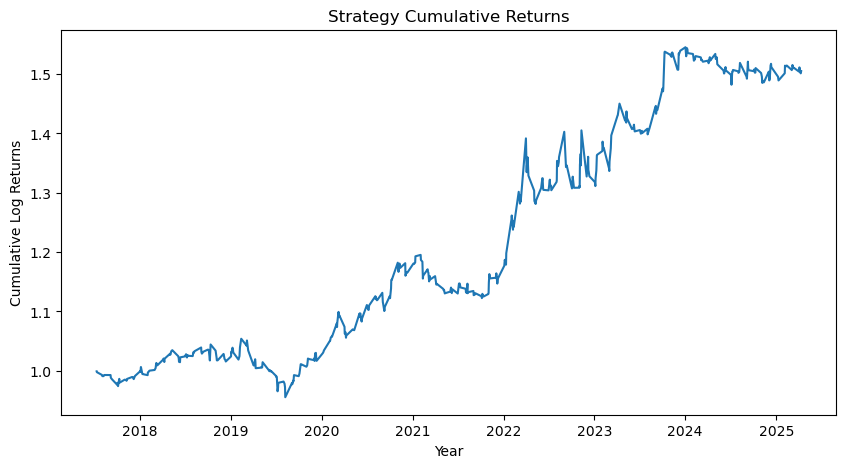

In [14]:
strat_ret = pred_df.groupby("Date")["StrategyReturns"].sum()

stratcumret = (1 + strat_ret).cumprod()
plt.figure(figsize=(10,5))
plt.plot(stratcumret)
plt.title("Strategy Cumulative Returns")
plt.xlabel("Year")
plt.ylabel("Cumulative Log Returns")
plt.savefig("cumulativeret.pdf")
plt.show()

Note that we haven't taken into account trading costs - let's assume below that we pay 5bps per trade. 

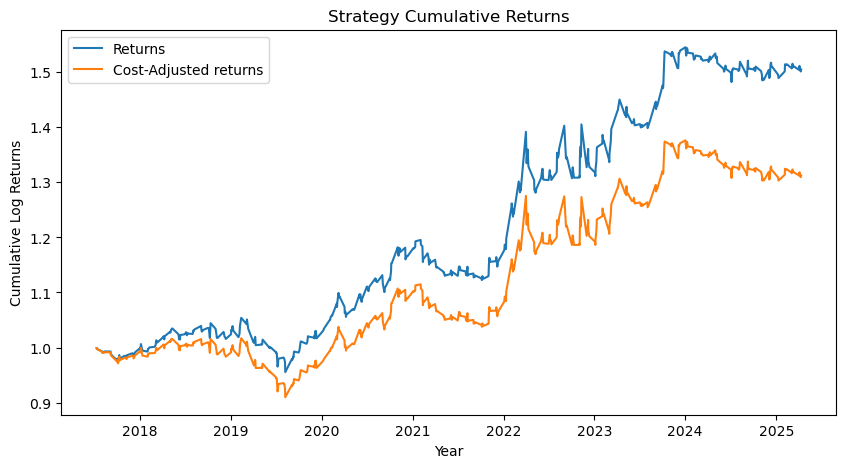

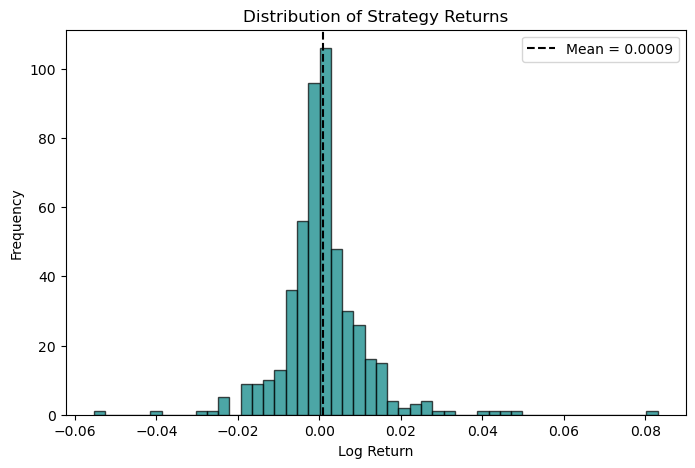

In [15]:
cost_per_trade = 0.0005 #Suppose we pay 5bps per trade
costs = daily_turnover * cost_per_trade
cost_adj_ret = strat_ret - costs
#Plot again...

stratcumret_adj = (1 + cost_adj_ret).cumprod()
plt.figure(figsize=(10,5))
plt.plot(stratcumret, label = "Returns")
plt.plot(stratcumret_adj, label = "Cost-Adjusted returns")
plt.title("Strategy Cumulative Returns")
plt.xlabel("Year")
plt.ylabel("Cumulative Log Returns")
plt.legend()
plt.savefig("cumulativeret_adj.pdf")
plt.show()

plt.figure(figsize=(8,5))
plt.hist(strat_ret, bins=50, alpha=0.7, color="teal", edgecolor="black")
plt.axvline(strat_ret.mean(), color="black", linestyle='--', label=f"Mean = {strat_ret.mean():.4f}")
plt.title("Distribution of Strategy Returns")
plt.xlabel("Log Return")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("retdist.pdf")
plt.show()

Computing the Sharpes:

In [16]:
print("Sharpe:", sharpe_ratio(strat_ret))
print("Cost Adjusted Sharpe:", sharpe_ratio(cost_adj_ret))
print("Max Drawdown:", max_drawdown(stratcumret))

Sharpe: 1.338092426070329
Cost Adjusted Sharpe: 0.9166599165395324
Max Drawdown: -0.09350306962007045


One might question these Sharpe ratios given that we are predicting h-day forward returns, but rebalancing the portfolio every day. Because in the ridge regression loop the prediction windows overlap, the daily returns are serially correlated, lowering the daily variance of the strategy.

We could either view this as an artificial inflation of the Sharpe ratios, or rather as a conscious portfolio construction choice. By trading every day we are systematically diversifying away our entry-timing risk. The calculated Sharpe ratio then reflects the risk-adjusted performance of this daily-rebalanced execution strategy.

However, it will prove interesting to evaluate how this daily turnover holds up against transaction costs. First, let's see how the Sharpe changes as a function of costs, assuming a basic linear transaction cost and no market impact.

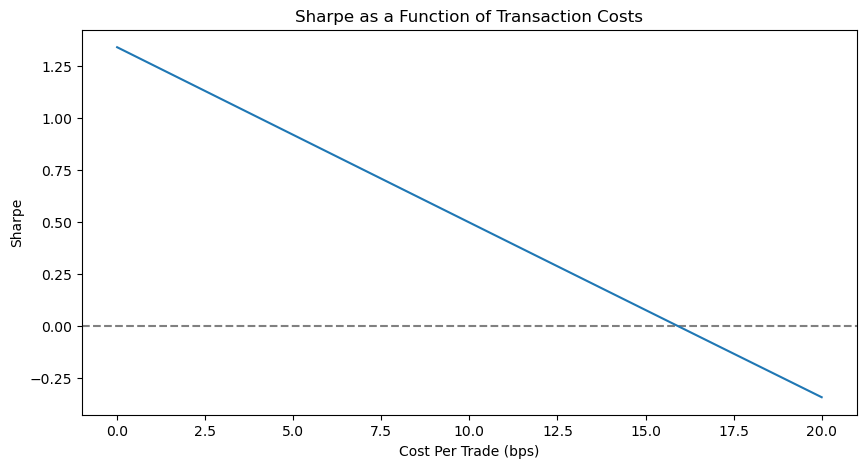

15.888700619321096


In [17]:
bps = [0, 2, 5, 7, 10, 12, 15, 17, 20]
sharpes = []
for bp in bps:
    bp_raw = bp * 1e-4
    costs = daily_turnover * bp_raw
    cost_adj_ret = strat_ret - costs
    sharpe = sharpe_ratio(cost_adj_ret)  
    sharpes.append(sharpe_ratio(cost_adj_ret))

plt.figure(figsize=(10,5))
plt.axhline(0.0, color = "gray", linestyle = "--")
plt.plot(bps, sharpes)
plt.title("Sharpe as a Function of Transaction Costs")
plt.xlabel("Cost Per Trade (bps)")
plt.ylabel("Sharpe")
plt.savefig("sharpevscosts.pdf")
plt.show()

i = np.where(np.diff(np.sign(sharpes)))[0][0] #sharpe changes sign at this index. np.sign takes the sign of each element, np.diff takes difference of
                                              #consecutive elements. np.diff(np.sign(sharpes)) is all zeros except for where the sign changes. np.where 
                                              #then gives you where the nonzero elements are; ie where that change happens.
x0, x1 = bps[i], bps[i+1] #We know the sharpe changes sign for a cost between bps[i] and bps[i+1]
y0, y1 = sharpes[i], sharpes[i+1] #We know that the sharpe at index i is positive and the sharpe at index i+1 is negative
bp_zero = x0 - y0 * (x1 - x0) / (y1 - y0) #linear interpolation, assume a straight line and find what cost sends sharpe negative.
print(bp_zero)

So assuming that trading costs are linear in the bps paid per trade, namely costs = daily_turnover * bp_raw, we see that the Sharpe hits zero at a cost of roughly 15.9 bps per trade. This seems rather high, but note that we have made no attempt to model market impact or slippage.

It would also be interesting to see how much of the strategy's returns are explained by the simple momentum feature. We can do this by a simple OLS regression of the strategy's returns against momentum.

In [18]:
weighted_mom = pred_df.groupby("Date").apply(lambda df: (df["Weight"] * df["Momentum"]).sum())

X = weighted_mom.values.reshape(-1, 1)
y = strat_ret.values
model = LinearRegression()
model.fit(X,y)

beta = model.coef_[0]
alpha = model.intercept_
r2 = model.score(X, y)

print(f"alpha: {alpha}")
print(f"beta (momentum exposure): {beta}")
print(f"R^2: {r2}")

alpha: 0.0001623695421882639
beta (momentum exposure): -0.0015209573960708446
R^2: 0.015560217946575472


The regression coefficients indicate that the strategy generates a daily return of ~0.0162% that is independent of momentum. The beta coefficient of -0.0015 tells us that the strategy has a slightly negative, but negligible, exposure to momentum. Moreover, an R^2 value of 0.0155 indicates that only ~1.56% of the variance in the strategy's returns are explained by its momentum exposure.

The coefficients suggest that the relative value strategy presented above is largely orthogonal to basic momentum. The interpretation is then that the predictive power and resulting alpha rely almost exclusively on the other features - the structure of the US treasury curve (spreads/flys) and the interactions. Regardless of momentum, the expected daily return from the strategy is 1.62bps, or an annualised expected return of 252 * alpha * 100 = 4.09%.

However, notice that we used the non-cost-adjusted returns to evaluate the strategy against momentum. If we use the cost-adjusted strategy returns, something different happens:

In [19]:
weighted_mom = pred_df.groupby("Date").apply(lambda df: (df["Weight"] * df["Momentum"]).sum())

X = weighted_mom.values.reshape(-1, 1)
y = cost_adj_ret.values
model = LinearRegression()
model.fit(X,y)

beta = model.coef_[0]
alpha = model.intercept_
r2 = model.score(X, y)

print(f"alpha: {alpha}")
print(f"beta (momentum exposure): {beta}")
print(f"R^2: {r2}")

alpha: -0.0009616245182659428
beta (momentum exposure): -0.001575661902443096
R^2: 0.01654575575403694


We find that when transaction costs are introduced, the model's beta to momentum remains effectively unchanged, but the alpha changes sign and becomes negative. Therefore, while our features may possess some predictive power orthogonal to basic momentum, the resulting alpha is highly sensitive to transaction costs. At 5 bps per trade, the trading costs arising from our naive daily rebalancing scheme completely erode the gross residual returns. The natural next step for is to move away from the daily rebalancing strategy and introduce some kind of turnover mitigation - perhaps a rules-based approach where we only trade if the dispersion in the weights is above some threshold. It would be interesting to see if the residual returns identified above survive transaction costs after a more sophisticated execution strategy.